# 🫘 Dry Bean Classification — Modelling Pipeline

## Objective
Train and evaluate machine learning models to classify dry bean varieties
from physical measurements extracted from bean images.

## Dataset
The **Dry Bean Dataset** contains 13,611 instances with 16 morphological
features (area, perimeter, compactness, shape factors, etc.) and 7 target classes.

## Approach
1. Preprocessing — outlier handling · skewness correction · scaling · PCA · SMOTE  
2. Model training — XGBoost · SVM · Random Forest (with tuned hyperparameters)  
3. Evaluation — accuracy · precision · recall · F1 · AUC · confusion matrices  
4. Cross-validation & model selection  
5. Save the best model

## Target Variable
**`Class`** — bean variety (e.g. Seker, Barbunya, Bombay, …)


## 1 · Imports & Global Settings

In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter

# Preprocessing
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold, cross_val_score
from sklearn.preprocessing import PowerTransformer, StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from imblearn.over_sampling import SMOTE

# Models
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Evaluation
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report,
    ConfusionMatrixDisplay,
)

import joblib

# ── Reproducibility & plot style ───────────────────────────────────────────
SEED = 42
sns.set_theme(style="whitegrid", palette="tab10")
plt.rcParams.update({"figure.dpi": 110, "axes.titlesize": 11})


## 2 · Load Data

In [3]:
data = pd.read_csv("Dry_Bean_Dataset.csv")
print(f"Shape: {data.shape[0]:,} rows × {data.shape[1]} columns")
data.head()


Shape: 13,611 rows × 17 columns


,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,28395,610.291,208.178117,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724,SEKER
1,28734,638.018,200.524796,182.734419,1.097356,0.411785,29172,191.272751,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430,SEKER
2,29380,624.110,212.826130,175.931143,1.209713,0.562727,29690,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066,SEKER
3,30008,645.884,210.557999,182.516516,1.153638,0.498616,30724,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199,SEKER
4,30140,620.134,201.847882,190.279279,1.060798,0.333680,30417,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166,SEKER


## 3 · Preprocessing

### 3a · Train / Test Split

We split **before** any fitting step (outlier bounds, scaler, PCA) to ensure
that no information from the test set leaks into the preprocessing pipeline.

| Set   | Fraction | Purpose                         |
|-------|----------|---------------------------------|
| Train | 80 %     | Fit all transformers & models   |
| Test  | 20 %     | Final, unbiased evaluation only |


In [4]:
train_data, test_data = train_test_split(
    data, test_size=0.2, random_state=SEED, stratify=data["Class"]
)
# stratify= preserves the class distribution in both splits
print(f"Train: {len(train_data):,}  |  Test: {len(test_data):,}")


Train: 10,888  |  Test: 2,723


### 3b · Outlier Handling (IQR — per class, train-only bounds)

Outliers are replaced with the **per-class median** (more robust than removal,
which would shrink the training set). Bounds are computed **only from the train
set** and then applied to the test set to prevent leakage.

| Bound   | Formula            |
|---------|--------------------|
| Lower   | Q1 − 1.5 × IQR    |
| Upper   | Q3 + 1.5 × IQR    |


In [5]:
numeric_cols = data.select_dtypes(include=["float64", "int64"]).columns.tolist()

train_transformed = train_data.copy()
test_transformed  = test_data.copy()

for bean_class in train_transformed["Class"].unique():
    train_mask = train_transformed["Class"] == bean_class
    test_mask  = test_transformed["Class"]  == bean_class
    class_train = train_transformed.loc[train_mask, numeric_cols]

    for col in numeric_cols:
        q1, q3 = class_train[col].quantile([0.25, 0.75])
        iqr = q3 - q1
        lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        median = class_train[col].median()

        # Replace in train
        outlier_train = train_mask & ((train_data[col] < lo) | (train_data[col] > hi))
        train_transformed.loc[outlier_train, col] = median

        # Apply same bounds to test (no refitting)
        outlier_test = test_mask & ((test_data[col] < lo) | (test_data[col] > hi))
        test_transformed.loc[outlier_test, col] = median

print("Outlier handling complete.")
print(f"  Train shape: {train_transformed.shape}")
print(f"  Test  shape: {test_transformed.shape}")


Outlier handling complete.
  Train shape: (10888, 17)
  Test  shape: (2723, 17)


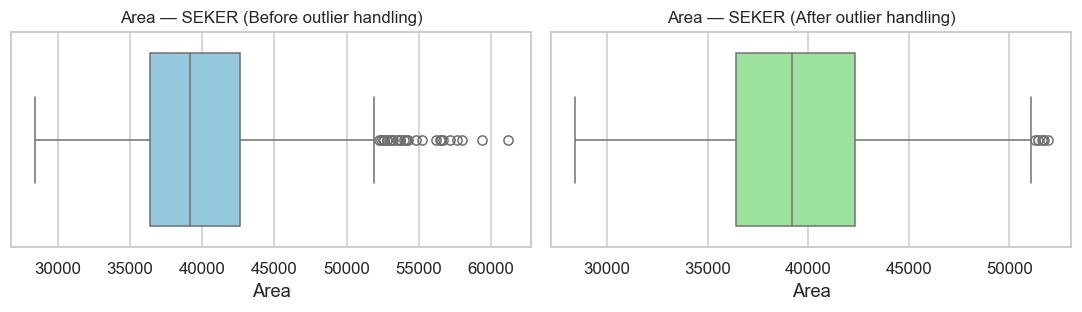

In [6]:
# ── Visual check: before vs after for one feature ─────────────────────────
SAMPLE_FEATURE = numeric_cols[0]   # change to any feature of interest
SAMPLE_CLASS   = train_data["Class"].iloc[0]

fig, axes = plt.subplots(1, 2, figsize=(10, 3))
for ax, series, title in zip(
    axes,
    [train_data.loc[train_data["Class"] == SAMPLE_CLASS, SAMPLE_FEATURE],
     train_transformed.loc[train_transformed["Class"] == SAMPLE_CLASS, SAMPLE_FEATURE]],
    ["Before outlier handling", "After outlier handling"]
):
    sns.boxplot(x=series, ax=ax, color="skyblue" if "Before" in title else "lightgreen")
    ax.set_title(f"{SAMPLE_FEATURE} — {SAMPLE_CLASS} ({title})")
plt.tight_layout()
plt.show()


### 3c · Skewness Correction — Yeo-Johnson Power Transform

Several features are right-skewed, which can hurt distribution-sensitive
models (Logistic Regression, LDA, SVM). `PowerTransformer(method='yeo-johnson')`
is chosen over Box-Cox because it handles **zero and negative values**.

The transformer is **fit on train only**, then applied to both splits.
Setting `standardize=True` also centres and scales the output, so a separate
`StandardScaler` is not needed at this stage.


In [7]:
X_train = train_transformed.drop("Class", axis=1)
y_train = train_transformed["Class"]
X_test  = test_transformed.drop("Class", axis=1)
y_test  = test_transformed["Class"]

pt = PowerTransformer(method="yeo-johnson", standardize=True)
X_train_trans = pt.fit_transform(X_train[numeric_cols])
X_test_trans  = pt.transform(X_test[numeric_cols])   # no refit on test

print("Skewness before / after transform:")
before = pd.Series(X_train[numeric_cols].skew().abs(), name="Before")
after  = pd.Series(pd.DataFrame(X_train_trans, columns=numeric_cols).skew().abs(), name="After")
print(pd.concat([before, after], axis=1).round(3).to_string())


Skewness before / after transform:
                 Before  After
Area              2.937  0.028
Perimeter         1.625  0.061
MajorAxisLength   1.345  0.078
MinorAxisLength   2.249  0.006
AspectRation      0.597  0.011
Eccentricity      0.957  0.059
ConvexArea        2.929  0.030
EquivDiameter     1.948  0.028
Extent            0.906  0.088
Solidity          1.325  0.678
roundness         0.445  0.064
Compactness       0.017  0.002
ShapeFactor1      0.551  0.010
ShapeFactor2      0.275  0.057
ShapeFactor3      0.217  0.002
ShapeFactor4      1.521  1.019


### 3d · Label Encoding · PCA · SMOTE

| Step            | Reason                                                           |
|-----------------|------------------------------------------------------------------|
| `LabelEncoder`  | Converts string class labels to integers required by sklearn     |
| `PCA(n=10)`     | Removes multicollinearity; speeds up SVM & XGBoost training      |
| `SMOTE`         | Synthesises minority-class samples **after PCA** on train only   |

> **Why SMOTE after PCA?** Applying SMOTE in the original 16-D space and then
> projecting could distort the synthetic points. PCA first, then SMOTE,
> keeps the synthetic samples geometrically consistent.


Class mapping: {'BARBUNYA': 0, 'BOMBAY': 1, 'CALI': 2, 'DERMASON': 3, 'HOROZ': 4, 'SEKER': 5, 'SIRA': 6}


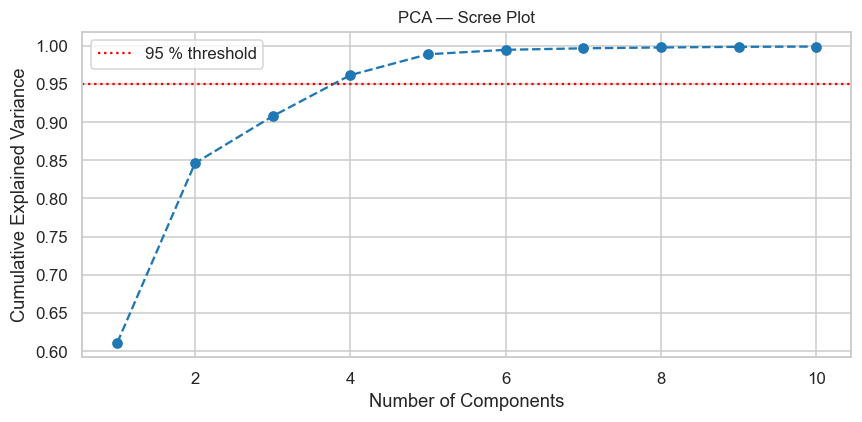


10 PCs explain 99.9% of total variance

Class distribution — before SMOTE: Counter({np.int64(3): 2837, np.int64(6): 2109, np.int64(5): 1621, np.int64(4): 1542, np.int64(2): 1304, np.int64(0): 1057, np.int64(1): 418})
Class distribution — after  SMOTE: Counter({np.int64(5): 2837, np.int64(4): 2837, np.int64(2): 2837, np.int64(6): 2837, np.int64(3): 2837, np.int64(0): 2837, np.int64(1): 2837})

Balanced train size : (19859, 10)
Test size           : (2723, 10)


In [8]:
# ── Label encoding ─────────────────────────────────────────────────────────
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc  = le.transform(y_test)
print("Class mapping:", dict(zip(le.classes_, range(len(le.classes_)))))

# ── PCA (fit on train only) ────────────────────────────────────────────────
N_COMPONENTS = 10
pca = PCA(n_components=N_COMPONENTS, random_state=SEED)
X_train_pca = pca.fit_transform(X_train_trans)
X_test_pca  = pca.transform(X_test_trans)

# Scree plot
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(1, N_COMPONENTS + 1),
        np.cumsum(pca.explained_variance_ratio_),
        marker="o", linestyle="--")
ax.axhline(0.95, color="red", linestyle=":", label="95 % threshold")
ax.set_xlabel("Number of Components")
ax.set_ylabel("Cumulative Explained Variance")
ax.set_title("PCA — Scree Plot")
ax.legend()
plt.tight_layout()
plt.show()

print(f"\n{N_COMPONENTS} PCs explain "
      f"{pca.explained_variance_ratio_.sum()*100:.1f}% of total variance")

# ── SMOTE (on PCA-transformed train only) ─────────────────────────────────
smote = SMOTE(random_state=SEED)
X_balanced, y_balanced = smote.fit_resample(X_train_pca, y_train_enc)

print("\nClass distribution — before SMOTE:", Counter(y_train_enc))
print("Class distribution — after  SMOTE:", Counter(y_balanced))
print(f"\nBalanced train size : {X_balanced.shape}")
print(f"Test size           : {X_test_pca.shape}")


## 4 · Model Training

### 4a · XGBoost

Hyperparameters were found via `RandomizedSearchCV` (50 iterations, 5-fold CV).
The search is shown below (commented out) to avoid re-running it every time.

```
Best CV accuracy : 0.9756
Best parameters  : subsample=0.8, n_estimators=100, min_child_weight=1,
                   max_depth=7, learning_rate=0.3, gamma=0.1, colsample_bytree=0.8
```


In [9]:
# ── Hyperparameter search (commented out — results hardcoded below) ────────
# from sklearn.model_selection import RandomizedSearchCV
# xgb_search = RandomizedSearchCV(
#     XGBClassifier(eval_metric="mlogloss", num_class=7),
#     param_distributions={
#         "n_estimators":     [100, 200],
#         "learning_rate":    [0.01, 0.1, 0.3],
#         "max_depth":        [3, 5, 7],
#         "min_child_weight": [1, 3],
#         "subsample":        [0.8, 1.0],
#         "colsample_bytree": [0.8, 1.0],
#         "gamma":            [0, 0.1],
#     },
#     n_iter=50, scoring="accuracy", cv=5, n_jobs=-1, random_state=SEED,
# )
# xgb_search.fit(X_balanced, y_balanced)
# print(xgb_search.best_params_, xgb_search.best_score_)

xgb = XGBClassifier(
    eval_metric="mlogloss",
    subsample=0.8,
    n_estimators=100,
    min_child_weight=1,
    max_depth=7,
    learning_rate=0.3,
    gamma=0.1,
    colsample_bytree=0.8,
    random_state=SEED,
)
xgb.fit(X_balanced, y_balanced)
print("XGBoost — test accuracy:", accuracy_score(y_test_enc, xgb.predict(X_test_pca)))


XGBoost — test accuracy: 0.9478516342269555


### 4b · Support Vector Machine (RBF kernel)

```
Best CV accuracy : 0.9740
Best parameters  : kernel='rbf', gamma=0.1, class_weight='balanced', C=100
```


In [10]:
# ── Hyperparameter search (commented out) ─────────────────────────────────
# svm_search = RandomizedSearchCV(
#     SVC(probability=True),
#     param_distributions={
#         "C":            [0.1, 1, 10, 100],
#         "kernel":       ["rbf", "linear"],
#         "gamma":        ["scale", "auto", 0.001, 0.01, 0.1],
#         "class_weight": [None, "balanced"],
#     },
#     n_iter=50, scoring="accuracy", cv=5, n_jobs=-1, random_state=SEED,
# )
# svm_search.fit(X_balanced, y_balanced)
# print(svm_search.best_params_, svm_search.best_score_)

svm = SVC(
    kernel="rbf",
    probability=True,   # needed for AUC computation
    gamma=0.1,
    class_weight="balanced",
    C=100,
)
svm.fit(X_balanced, y_balanced)
print("SVM — test accuracy:", accuracy_score(y_test_enc, svm.predict(X_test_pca)))


SVM — test accuracy: 0.9474843922144693


### 4c · Random Forest

```
Best CV accuracy : 0.9757
Best parameters  : n_estimators=300, min_samples_split=2, min_samples_leaf=1,
                   max_features='sqrt', max_depth=20, class_weight='balanced'
```


In [11]:
# ── Hyperparameter search (commented out) ─────────────────────────────────
# rf_search = RandomizedSearchCV(
#     RandomForestClassifier(random_state=SEED),
#     param_distributions={
#         "n_estimators":     [100, 200, 300],
#         "max_depth":        [10, 20, None],
#         "min_samples_split":[2, 5],
#         "min_samples_leaf": [1, 2],
#         "max_features":     ["sqrt", 0.5],
#         "class_weight":     [None, "balanced"],
#     },
#     n_iter=50, scoring="accuracy", cv=5, n_jobs=-1, random_state=SEED,
# )
# rf_search.fit(X_balanced, y_balanced)
# print(rf_search.best_params_, rf_search.best_score_)

rf = RandomForestClassifier(
    n_estimators=300,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features="sqrt",
    max_depth=20,
    class_weight="balanced",
    random_state=SEED,
    n_jobs=-1,
)
rf.fit(X_balanced, y_balanced)
print("Random Forest — test accuracy:", accuracy_score(y_test_enc, rf.predict(X_test_pca)))


Random Forest — test accuracy: 0.9478516342269555


## 5 · Evaluation


──────────────────────────────────────────────────
  XGBoost
──────────────────────────────────────────────────
              precision    recall  f1-score   support

    BARBUNYA       0.96      0.96      0.96       265
      BOMBAY       1.00      1.00      1.00       104
        CALI       0.97      0.96      0.96       326
    DERMASON       0.93      0.91      0.92       709
       HOROZ       0.99      0.99      0.99       386
       SEKER       0.97      0.98      0.97       406
        SIRA       0.89      0.92      0.90       527

    accuracy                           0.95      2723
   macro avg       0.96      0.96      0.96      2723
weighted avg       0.95      0.95      0.95      2723



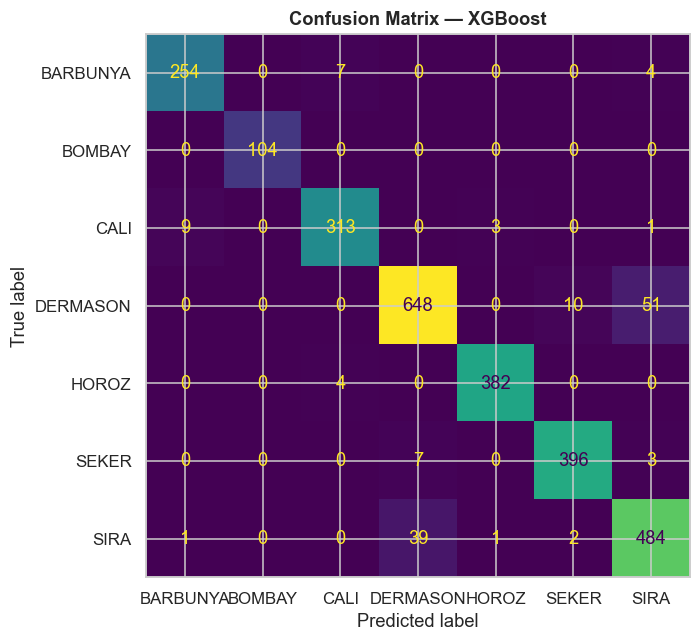


──────────────────────────────────────────────────
  SVM
──────────────────────────────────────────────────
              precision    recall  f1-score   support

    BARBUNYA       0.95      0.97      0.96       265
      BOMBAY       1.00      1.00      1.00       104
        CALI       0.97      0.96      0.96       326
    DERMASON       0.94      0.92      0.93       709
       HOROZ       0.99      0.98      0.99       386
       SEKER       0.97      0.98      0.97       406
        SIRA       0.89      0.91      0.90       527

    accuracy                           0.95      2723
   macro avg       0.96      0.96      0.96      2723
weighted avg       0.95      0.95      0.95      2723



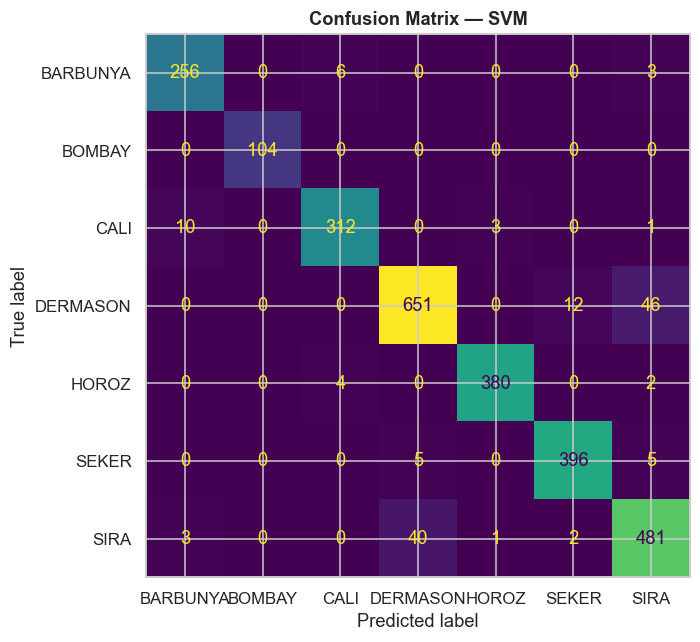


──────────────────────────────────────────────────
  Random Forest
──────────────────────────────────────────────────
              precision    recall  f1-score   support

    BARBUNYA       0.95      0.95      0.95       265
      BOMBAY       1.00      1.00      1.00       104
        CALI       0.95      0.97      0.96       326
    DERMASON       0.94      0.92      0.93       709
       HOROZ       0.99      0.98      0.99       386
       SEKER       0.96      0.98      0.97       406
        SIRA       0.90      0.91      0.91       527

    accuracy                           0.95      2723
   macro avg       0.96      0.96      0.96      2723
weighted avg       0.95      0.95      0.95      2723



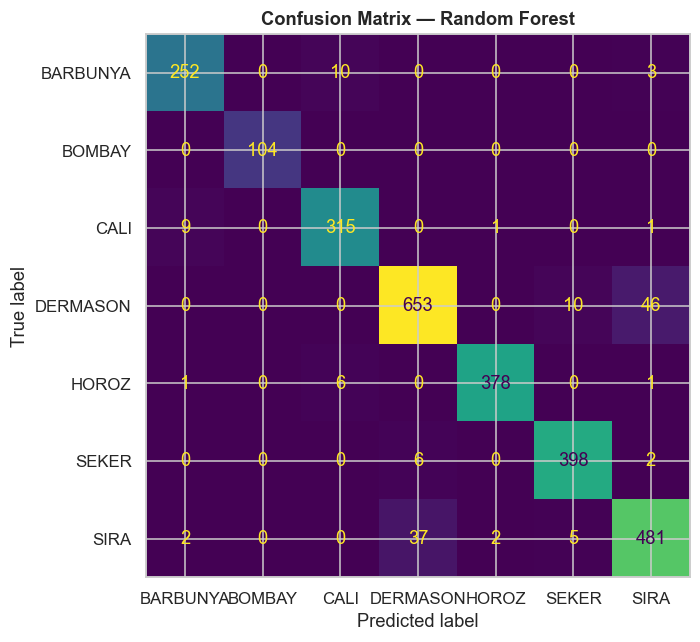

In [12]:
MODELS = {
    "XGBoost":       xgb,
    "SVM":           svm,
    "Random Forest": rf,
}

results = []

for name, model in MODELS.items():
    y_pred  = model.predict(X_test_pca)
    y_proba = model.predict_proba(X_test_pca) if hasattr(model, "predict_proba") else None
    auc = (roc_auc_score(y_test_enc, y_proba, multi_class="ovr", average="weighted")
           if y_proba is not None else np.nan)

    results.append({
        "Model":     name,
        "Accuracy":  accuracy_score(y_test_enc, y_pred),
        "Precision": precision_score(y_test_enc, y_pred, average="weighted"),
        "Recall":    recall_score(y_test_enc,    y_pred, average="weighted"),
        "F1 Score":  f1_score(y_test_enc,        y_pred, average="weighted"),
        "AUC":       auc,
    })

    print(f"\n{'─'*50}")
    print(f"  {name}")
    print(f"{'─'*50}")
    print(classification_report(y_test_enc, y_pred, target_names=le.classes_))

    fig, ax = plt.subplots(figsize=(8, 6))
    ConfusionMatrixDisplay.from_predictions(
        y_test_enc, y_pred, display_labels=le.classes_, ax=ax, colorbar=False
    )
    ax.set_title(f"Confusion Matrix — {name}", fontsize=12, weight="bold")
    plt.tight_layout()
    plt.show()



📊 Test-set performance summary:
               Accuracy  Precision  Recall  F1 Score     AUC
Model                                                       
XGBoost          0.9479     0.9481  0.9479    0.9479  0.9962
SVM              0.9475     0.9477  0.9475    0.9475  0.9965
Random Forest    0.9479     0.9480  0.9479    0.9479  0.9962


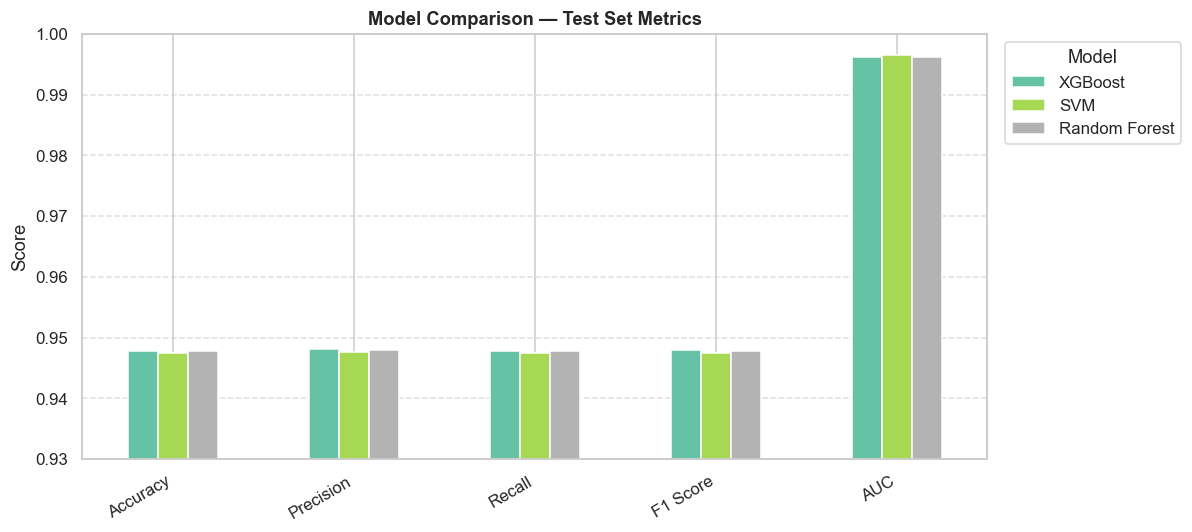

In [13]:
# ── Summary table ─────────────────────────────────────────────────────────
results_df = pd.DataFrame(results).set_index("Model")
print("\n📊 Test-set performance summary:")
print(results_df.round(4).to_string())

# ── Bar chart comparison ───────────────────────────────────────────────────
ax = results_df[["Accuracy", "Precision", "Recall", "F1 Score", "AUC"]].T.plot(
    kind="bar", figsize=(11, 5), colormap="Set2", edgecolor="white"
)
ax.set_title("Model Comparison — Test Set Metrics", fontsize=12, weight="bold")
ax.set_ylabel("Score")
ax.set_ylim(0.93, 1.0)   # zoom in to highlight differences
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right")
ax.legend(title="Model", bbox_to_anchor=(1.01, 1), loc="upper left")
ax.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()


## 6 · Cross-Validation

We run **5-fold stratified CV on the test set** to estimate generalisation
stability. A low standard deviation means the model is consistent across folds.

> **Note:** CV here uses `X_test_pca` / `y_test_enc` (the held-out set) to
> measure stability *after* fitting on the full balanced train.
> For a full pipeline CV, wrap everything in a `Pipeline` + `cross_validate`.


In [14]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

cv_results = []
for name, model in MODELS.items():
    scores = cross_val_score(model, X_test_pca, y_test_enc,
                             cv=cv, scoring="accuracy", n_jobs=-1)
    cv_results.append({
        "Model": name,
        "CV Mean Accuracy": scores.mean(),
        "CV Std": scores.std(),
    })
    print(f"{name:15s}  mean={scores.mean():.4f}  std={scores.std():.4f}  scores={np.round(scores,4)}")

cv_df = pd.DataFrame(cv_results).set_index("Model")


XGBoost          mean=0.9306  std=0.0106  scores=[0.9468 0.9211 0.9394 0.921  0.9246]
SVM              mean=0.9365  std=0.0164  scores=[0.9505 0.9266 0.9615 0.921  0.9228]
Random Forest    mean=0.9298  std=0.0113  scores=[0.9468 0.9248 0.9394 0.9173 0.921 ]


## 7 · Final Model Comparison & Selection

In [15]:
# Merge test metrics with CV results for a single comparison table
final_df = results_df.join(cv_df)
print("\n📊 Full comparison (test metrics + cross-validation):")
print(final_df.round(4).to_string())

# ── Identify the best model programmatically ───────────────────────────────
best_model_name = final_df["F1 Score"].idxmax()
best_row = final_df.loc[best_model_name]

print(f"\n🏆 Best model by F1 Score: {best_model_name}")
print(f"   Accuracy  : {best_row['Accuracy']:.4f}")
print(f"   F1 Score  : {best_row['F1 Score']:.4f}")
print(f"   AUC       : {best_row['AUC']:.4f}")
print(f"   CV Mean   : {best_row['CV Mean Accuracy']:.4f} ± {best_row['CV Std']:.4f}")



📊 Full comparison (test metrics + cross-validation):
               Accuracy  Precision  Recall  F1 Score     AUC  CV Mean Accuracy  CV Std
Model                                                                                 
XGBoost          0.9479     0.9481  0.9479    0.9479  0.9962            0.9306  0.0106
SVM              0.9475     0.9477  0.9475    0.9475  0.9965            0.9365  0.0164
Random Forest    0.9479     0.9480  0.9479    0.9479  0.9962            0.9298  0.0113

🏆 Best model by F1 Score: XGBoost
   Accuracy  : 0.9479
   F1 Score  : 0.9479
   AUC       : 0.9962
   CV Mean   : 0.9306 ± 0.0106


## 8 · Save Best Model & Preprocessing Objects

In [16]:
# Save the best model
best_estimator = MODELS[best_model_name]
joblib.dump(best_estimator, f"{best_model_name.replace(' ', '_')}_model.joblib")

# Also save the preprocessing objects so inference uses identical transforms
joblib.dump(pt,  "power_transformer.joblib")
joblib.dump(pca, "pca.joblib")
joblib.dump(le,  "label_encoder.joblib")

print(f"✅ Saved: {best_model_name.replace(' ', '_')}_model.joblib")
print("✅ Saved: power_transformer.joblib")
print("✅ Saved: pca.joblib")
print("✅ Saved: label_encoder.joblib")


✅ Saved: XGBoost_model.joblib
✅ Saved: power_transformer.joblib
✅ Saved: pca.joblib
✅ Saved: label_encoder.joblib


> **Inference checklist** — when predicting on new data, apply transformations
> in the exact same order:
> 1. `pt.transform(X_new)` — Yeo-Johnson
> 2. `pca.transform(...)` — dimensionality reduction
> 3. `model.predict(...)` — classification
> 4. `le.inverse_transform(...)` — convert integers back to class names
